# Chapter 7: 二次型 (Quadratic Forms)

本章我们将探讨线性代数中一个极其优美的领域——二次型。不仅因为它是解析几何中处理旋转圆锥曲线的钥匙，更因为它在现代深度学习中扮演着判别“损失函数地形”的关键角色（正定性与Hessian矩阵）。我们将从矩阵表示出发，经历代数的“配方法”与几何的“主轴定理”，最终学会如何通过坐标变换“拉直”倾斜的空间。

## 7.1 二次型的矩阵表示与计算
一个 $n$ 元二次型 $f(x)$ 可以唯一地写成 $f(\mathbf{x}) = \mathbf{x}^T A \mathbf{x}$ 的形式，其中 $A$ 必须是对称矩阵。交叉项（如 $x_1 x_2$）的存在意味着几何体的主轴没有与坐标轴对齐。

### 首先定义一个计算二次型的通用函数，并验证对称性的重要性。

In [2]:
import torch

# 基础设置
torch.manual_seed(42)

def quadratic_form(x: torch.Tensor, A: torch.Tensor) -> torch.Tensor:
    """
    计算二次型 f(x) = x^T A x
    
    参数:
        x: 向量, shape (n,)
        A: 矩阵, shape (n, n)
    返回:
        标量值
    """
    # 矩阵乘法: (1, n) @ (n, n) @ (n, 1) -> scalar
    # 注意: torch.dot 仅适用于 1D 向量点积，这里涉及矩阵运算，推荐使用 @ 或 matmul
    return x.T @ A @ x

# --- 示例：二维二次型 5x^2 - 6xy + 5y^2 ---
# 交叉项 -6xy 分配给 a_12 和 a_21，每个为 -3
A = torch.tensor([[5.0, -3.0],
                  [-3.0, 5.0]])

# 定义一个输入向量 x = [1, 2]
x = torch.tensor([1.0, 2.0])

# 计算值: 5(1)^2 - 6(1)(2) + 5(2)^2 = 5 - 12 + 20 = 13
f_val = quadratic_form(x, A)

print(f"矩阵 A:\n{A}")
print(f"向量 x: {x}")
print(f"二次型 f(x) 的值: {f_val.item()}")

# --- 验证对称性的必要性 ---
# 如果 A 不对称，比如把 -6 全部放在 a_12，a_21=0
A_nonsym = torch.tensor([[5.0, -6.0],
                         [0.0, 5.0]])
f_val_nonsym = quadratic_form(x, A_nonsym)

print(f"\n非对称矩阵计算结果: {f_val_nonsym.item()}")
print("结论：虽然计算结果相同，但只有对称矩阵具有实特征值和正交特征向量等优美性质。")

矩阵 A:
tensor([[ 5., -3.],
        [-3.,  5.]])
向量 x: tensor([1., 2.])
二次型 f(x) 的值: 13.0

非对称矩阵计算结果: 13.0
结论：虽然计算结果相同，但只有对称矩阵具有实特征值和正交特征向量等优美性质。


## 7.2 合同变换：代数视角的“消交叉项”
拉格朗日的配方法（Completing the Square）在矩阵语言下对应合同变换：$B = C^T A C$。这种变换可以将 $A$ 化为对角阵，从而消除交叉项。但要注意，这种变换通常包含剪切（Shear）和拉伸，并非保持几何形状的刚性旋转。

### 下面的代码验证书中的例子：通过非正交的线性变换 $C$，将非对角矩阵 $A$ 转化为对角矩阵 $B$。

In [3]:
import torch

# 原始矩阵 A (对应 f = x_1^2 - 4x_1x_2 + 5x_2^2)
A = torch.tensor([[1.0, -2.0],
                  [-2.0, 5.0]])

# 配方法得到的变换矩阵 C (来自书中的推导)
# x = C y => [x1, x2]^T = [[1, 2], [0, 1]] [y1, y2]^T
C = torch.tensor([[1.0, 2.0],
                  [0.0, 1.0]])

# 执行合同变换 B = C^T A C
# 注意顺序：先 C^T @ A，再 @ C
B = C.T @ A @ C

print("原始矩阵 A:\n", A)
print("变换矩阵 C (对应配方法):\n", C)
print("合同变换后的矩阵 B = C^T A C:\n", B)

# 验证是否对角化
is_diagonal = torch.allclose(B, torch.diag(torch.diag(B)))
print(f"\n矩阵 B 是否为对角阵? {is_diagonal}")
if is_diagonal:
    print("交叉项已成功消除！新坐标下的形式为: y_1^2 + y_2^2")

原始矩阵 A:
 tensor([[ 1., -2.],
        [-2.,  5.]])
变换矩阵 C (对应配方法):
 tensor([[1., 2.],
        [0., 1.]])
合同变换后的矩阵 B = C^T A C:
 tensor([[1., 0.],
        [0., 1.]])

矩阵 B 是否为对角阵? True
交叉项已成功消除！新坐标下的形式为: y_1^2 + y_2^2


## 7.3 正定性：深度学习中的“碗”与“鞍”

在深度学习优化中，我们极度关注 Hessian 矩阵（二次型）的正定性。

正定 (Positive Definite)：对应局部极小值（碗底），容易优化。

不定 (Indefinite)：对应鞍点（Saddle Point），一个方向向上弯，一个方向向下弯，是优化的陷阱。

### 实现多种正定性判别法（特征值法、Cholesky法），并绘制 3D 图来直观感受“正定”与“不定”的几何区别。

--- 分析 A_bowl (碗) ---
特征值: [2. 2.]
判定: 正定 (Positive Definite)
Cholesky分解: 成功 (是正定矩阵)


--- 分析 A_saddle (马鞍) ---
特征值: [-2.  2.]
判定: 不定 (Indefinite) -> 鞍点风险!
Cholesky分解: 失败 (非正定)


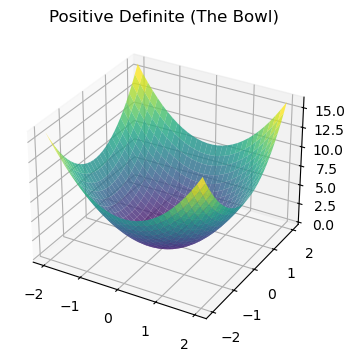

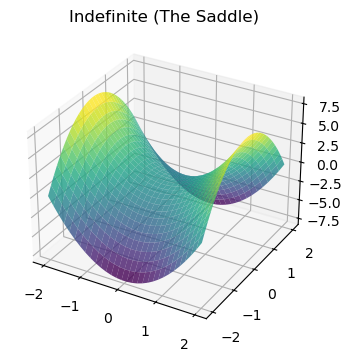

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def analyze_definiteness(A, name="Matrix"):
    """综合分析矩阵的正定性"""
    print(f"--- 分析 {name} ---")
    
    # 1. 特征值判别法 (最本质)
    eigs = torch.linalg.eigvalsh(A) # eigvalsh 专用于对称矩阵
    print(f"特征值: {eigs.numpy()}")
    
    if torch.all(eigs > 0):
        print("判定: 正定 (Positive Definite)")
    elif torch.all(eigs >= 0):
        print("判定: 半正定 (Positive Semidefinite)")
    elif torch.all(eigs < 0):
        print("判定: 负定 (Negative Definite)")
    else:
        print("判定: 不定 (Indefinite) -> 鞍点风险!")

    # 2. Cholesky 分解判别 (最快，常用于计算)
    try:
        L = torch.linalg.cholesky(A)
        print("Cholesky分解: 成功 (是正定矩阵)")
    except RuntimeError:
        print("Cholesky分解: 失败 (非正定)")

# 定义两个典型的矩阵
A_bowl = torch.tensor([[2.0, 0.0], [0.0, 2.0]])   # 正定：碗
A_saddle = torch.tensor([[2.0, 0.0], [0.0, -2.0]]) # 不定：马鞍

analyze_definiteness(A_bowl, "A_bowl (碗)")
print("\n")
analyze_definiteness(A_saddle, "A_saddle (马鞍)")

# --- 可视化 (需要 matplotlib) ---
def plot_surface_3d(A, title):
    x = np.linspace(-2, 2, 30)
    y = np.linspace(-2, 2, 30)
    X, Y = np.meshgrid(x, y)
    
    # 计算 Z = ax^2 + by^2 + 2cxy (这里简单起见手动展开，通用的需用 einsum)
    # f(x) = a11 x^2 + 2 a12 xy + a22 y^2
    Z = A[0,0].item() * X**2 + 2 * A[0,1].item() * X * Y + A[1,1].item() * Y**2
    
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    ax.set_title(title)
    return fig

# 
fig1 = plot_surface_3d(A_bowl, "Positive Definite (The Bowl)")
# 
fig2 = plot_surface_3d(A_saddle, "Indefinite (The Saddle)")
plt.show()

### 西尔维斯特判别法（顺序主子式）
书中提到了“西尔维斯特顺序主子式判别法”。虽然我们在前面的代码里用 Cholesky 做了判定，但为了让读者理解“顺序主子式”这个概念在代码中是如何通过 slice 操作实现的，我们需要一个专门的函数。这有助于强化对矩阵分块操作的理解。

In [8]:
import torch

def sylvester_criterion(A: torch.Tensor) -> bool:
    """
    使用西尔维斯特准则（顺序主子式）判断矩阵是否正定。
    判定标准：所有顺序主子式的行列式都必须 > 0。
    """
    n = A.shape[0]
    print(f"--- 正在检查 {n}x{n} 矩阵的顺序主子式 ---")
    
    for k in range(1, n + 1):
        # 提取 k x k 的左上角子矩阵 (切片操作)
        sub_matrix = A[:k, :k]
        
        # 计算行列式
        det_val = torch.linalg.det(sub_matrix).item()
        
        print(f"k={k}: 子矩阵行列式 = {det_val:.4f}")
        
        # 只要有一个 <= 0，立即判定非正定
        if det_val <= 1e-6: # 使用一个小阈值处理浮点误差
            print(f"-> 在第 {k} 阶主子式检测失败 (det <= 0)")
            return False
            
    print("-> 所有顺序主子式均为正，矩阵正定。")
    return True

# --- 测试案例 ---
# 案例 1: 正定矩阵 (例如: 2x^2 + 2y^2)
A_pos = torch.tensor([[2.0, 0.0], 
                      [0.0, 2.0]])

# 案例 2: 不定矩阵 (例如: 2x^2 - 2y^2)
# 注意：虽然 det(A) = -4 < 0，但第一阶 det=2 > 0，所以需要循环检查
A_indef = torch.tensor([[2.0, 0.0], 
                        [0.0, -2.0]])

print("检测 A_pos:")
sylvester_criterion(A_pos)

print("\n检测 A_indef:")
sylvester_criterion(A_indef)

检测 A_pos:
--- 正在检查 2x2 矩阵的顺序主子式 ---
k=1: 子矩阵行列式 = 2.0000
k=2: 子矩阵行列式 = 4.0000
-> 所有顺序主子式均为正，矩阵正定。

检测 A_indef:
--- 正在检查 2x2 矩阵的顺序主子式 ---
k=1: 子矩阵行列式 = 2.0000
k=2: 子矩阵行列式 = -4.0000
-> 在第 2 阶主子式检测失败 (det <= 0)


False

### AI视角 —— 梯度下降在“碗”与“马鞍”上的不同命运
这是连接线性代数与深度学习最“硬核”的部分。书中提到了 Hessian 矩阵决定了地形。如果不写一段代码让小球（梯度下降）真的在上面跑一跑，读者就无法直观体会为什么“正定性”对训练收敛如此重要。

开始优化矩阵 A (特征值: [2. 5.])
开始优化矩阵 A (特征值: [-2.  2.])


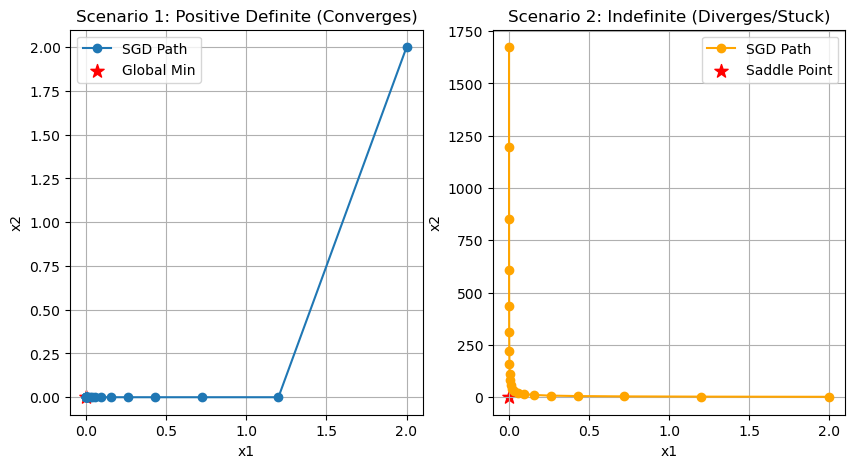

左图（Scenario 1） 展示了一个理想的收敛过程。
右图（Scenario 2） 展示了一个典型的“梯度爆炸”或朝向负无穷发散的过程，这正是鞍点（Saddle Point）或者不定矩阵带来的后果。


In [11]:
import torch
import matplotlib.pyplot as plt

def simulate_gradient_descent(A, start_point, lr=0.1, steps=20):
    """
    模拟在二次型曲面 f(x) = x^T A x 上的梯度下降轨迹
    """
    # 必须开启 requires_grad 以自动计算梯度
    x = start_point.clone().detach().requires_grad_(True)
    trajectory = [x.detach().numpy().copy()]
    
    print(f"开始优化矩阵 A (特征值: {torch.linalg.eigvalsh(A).numpy()})")
    
    for i in range(steps):
        # 1. 前向传播：计算 Loss = x^T A x
        loss = x.T @ A @ x
        
        # 2. 反向传播：计算梯度
        loss.backward()
        
        # 3. 梯度更新 (SGD)
        with torch.no_grad():
            x -= lr * x.grad
            # 清零梯度，为下一次迭代做准备
            x.grad.zero_()
            
        trajectory.append(x.detach().numpy().copy())
    
    return np.array(trajectory)

# --- 准备数据 ---
# 场景 1: 完美的碗 (正定, 特征值均为正)
A_bowl = torch.tensor([[2.0, 0.0], [0.0, 5.0]]) 

# 场景 2: 致命的马鞍 (不定, 特征值一正一负)
A_saddle = torch.tensor([[2.0, 0.0], [0.0, -2.0]])

start = torch.tensor([2.0, 2.0]) # 起始点

# --- 运行模拟 ---
traj_bowl = simulate_gradient_descent(A_bowl, start)
traj_saddle = simulate_gradient_descent(A_saddle, start)

# --- 可视化轨迹 ---
plt.figure(figsize=(10, 5))

# 绘制碗形轨迹
plt.subplot(1, 2, 1)
plt.plot(traj_bowl[:, 0], traj_bowl[:, 1], 'o-', label='SGD Path')
plt.scatter(0, 0, c='red', marker='*', s=100, label='Global Min') # 目标点
plt.title("Scenario 1: Positive Definite (Converges)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.grid(True)
plt.legend()

# 绘制马鞍形轨迹
plt.subplot(1, 2, 2)
plt.plot(traj_saddle[:, 0], traj_saddle[:, 1], 'o-', color='orange', label='SGD Path')
plt.scatter(0, 0, c='red', marker='*', s=100, label='Saddle Point')
plt.title("Scenario 2: Indefinite (Diverges/Stuck)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.grid(True)
plt.legend()

plt.show()

print("左图（Scenario 1） 展示了一个理想的收敛过程。") 
print("右图（Scenario 2） 展示了一个典型的“梯度爆炸”或朝向负无穷发散的过程，这正是鞍点（Saddle Point）或者不定矩阵带来的后果。")    

## 7.4 主轴定理与谱分解：寻找自然的坐标系
不同于配方法的“暴力”对角化，主轴定理（Principal Axis Theorem） 使用正交变换 $P$（旋转）将 $A$ 对角化。
这不仅仅是代数化简，更是寻找几何体固有对称轴的过程。
公式：$P^T A P = \Lambda$，其中 $P$ 的列向量是特征向量，$\Lambda$ 的对角元是特征值。

### 谱分解代码实现

In [5]:
import torch

# 构造一个随机的对称矩阵
torch.manual_seed(0)
X = torch.randn(3, 3)
A = X + X.T  # 确保对称

print("对称矩阵 A:\n", A)

# 1. 谱分解 (Spectral Decomposition)
# eigh 返回特征值 (升序) 和 对应的特征向量矩阵 P
eigvals, P = torch.linalg.eigh(A)

print("\n特征值 (Eigenvalues):\n", eigvals)
print("特征向量矩阵 P (Orthogonal Matrix):\n", P)

# 2. 验证 P 是否为正交矩阵 (P^T P = I)
I_approx = P.T @ P
is_orthogonal = torch.allclose(I_approx, torch.eye(3), atol=1e-6)
print(f"\n验证 P 是否正交 (P^T @ P ≈ I): {is_orthogonal}")

# 3. 验证对角化 (P^T A P = Lambda)
Lambda_approx = P.T @ A @ P
# 创建纯对角特征值矩阵
Lambda_true = torch.diag(eigvals)

print("重构误差 (P^T A P - Lambda):", (Lambda_approx - Lambda_true).abs().max().item())

# 4. 谱定理重构 (Reconstruction): A = sum(lambda_i * v_i * v_i^T)
# 也是 PCA 降维的数学基础
A_recon = P @ Lambda_true @ P.T
print("原始矩阵 A 与重构矩阵是否一致?", torch.allclose(A, A_recon, atol=1e-6))

对称矩阵 A:
 tensor([[ 3.0820,  0.2750, -1.7754],
        [ 0.2750, -2.1690, -0.5606],
        [-1.7754, -0.5606, -1.4385]])

特征值 (Eigenvalues):
 tensor([-2.5725, -1.6825,  3.7294])
特征向量矩阵 P (Orthogonal Matrix):
 tensor([[ 0.1598, -0.2998, -0.9405],
        [ 0.7624,  0.6427, -0.0753],
        [ 0.6271, -0.7050,  0.3313]])

验证 P 是否正交 (P^T @ P ≈ I): True
重构误差 (P^T A P - Lambda): 4.76837158203125e-07
原始矩阵 A 与重构矩阵是否一致? True


### 瑞利商 (Rayleigh Quotient) 的数值验证
书中专门提到了“瑞利商与极值原理”，并指出 PCA 的核心就是最大化这个商。仅仅给公式不够直观，我们需要通过代码随机采样大量向量，证明 $x^T A x / x^T x$ 的值确实被限制在最小和最大特征值之间。

特征值范围: [0.1276, 2.7999]


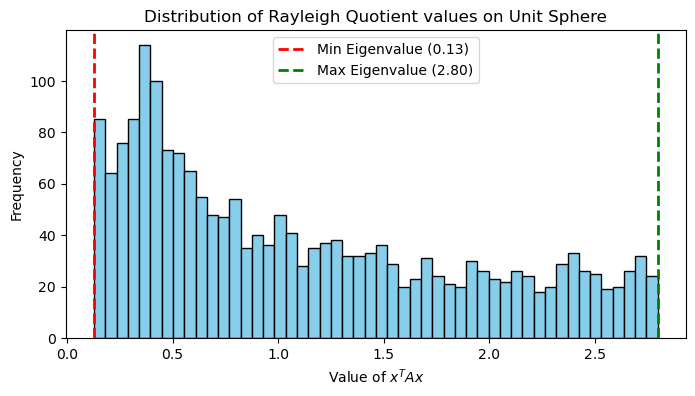

验证结论：所有的瑞利商采样值都严格落在最小和最大特征值之间。


In [10]:
import torch
import matplotlib.pyplot as plt

# 1. 定义一个对称矩阵
torch.manual_seed(123)
X = torch.randn(3, 3)
A = X @ X.T # 构造成半正定，保证特征值非负方便观察，或者直接 X+X.T

# 2. 计算理论上的界限 (特征值)
eigvals = torch.linalg.eigvalsh(A)
lambda_min = eigvals[0].item()
lambda_max = eigvals[-1].item()

print(f"特征值范围: [{lambda_min:.4f}, {lambda_max:.4f}]")

# 3. 蒙特卡洛实验：随机生成大量单位向量，计算瑞利商
num_samples = 2000
# 生成随机方向 (正态分布采样后归一化)
vecs = torch.randn(3, num_samples) 
vecs = vecs / torch.norm(vecs, dim=0) # 归一化，使得 x^T x = 1

# 批量计算瑞利商 R(x) = x^T A x (因为分母为1)
# 技巧：使用 einsum 进行批量双线性形式计算 'ij, jk, ik -> i' (转置处理后)
# 或者简单的: diag(V.T @ A @ V)
rayleigh_quotients = torch.sum(vecs * (A @ vecs), dim=0)

# 4. 可视化分布
plt.figure(figsize=(8, 4))
plt.hist(rayleigh_quotients.numpy(), bins=50, color='skyblue', edgecolor='black')
plt.axvline(lambda_min, color='r', linestyle='--', linewidth=2, label=f'Min Eigenvalue ({lambda_min:.2f})')
plt.axvline(lambda_max, color='g', linestyle='--', linewidth=2, label=f'Max Eigenvalue ({lambda_max:.2f})')

plt.title("Distribution of Rayleigh Quotient values on Unit Sphere")
plt.xlabel("Value of $x^T A x$")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print("验证结论：所有的瑞利商采样值都严格落在最小和最大特征值之间。")

## 7.5 综合范例：旋转椭圆的几何复原
我们有一个带有交叉项的方程 $5x_1^2 - 6x_1x_2 + 5x_2^2 = 8$，这是一个倾斜的椭圆。我们的目标是：计算特征值 $\lambda_1, \lambda_2$，它们决定了椭圆的长短轴长度。计算特征向量矩阵 $P$，它决定了椭圆旋转的角度。可视化：先生成标准椭圆，再用 $P$ 将其旋转回原方程描述的位置。

### 旋转旋转椭圆的几何复原代码实现

特征值: [2. 8.]
旋转矩阵 P:
[[ 0.70710677 -0.70710677]
 [ 0.70710677  0.70710677]]
椭圆半轴长: 2.0000, 1.0000


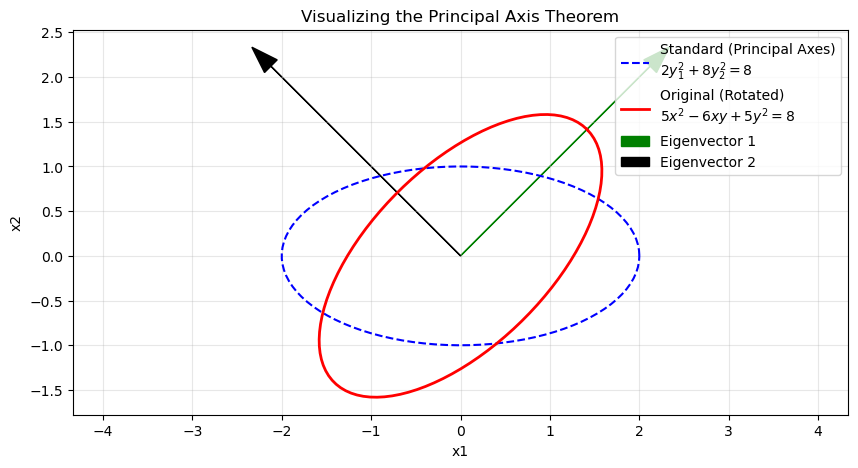

验证点 [0.71957487 1.5580733 ] 代入原方程: 8.0000 (应接近 8.0)


In [12]:
import torch
import math
import matplotlib.pyplot as plt

# 1. 定义矩阵 A
A = torch.tensor([[5.0, -3.0],
                  [-3.0, 5.0]])
RHS = 8.0 # 方程右边的常数

# 2. 求解特征体系
# eigvals 对应轴长的倒数平方关系: lambda = RHS / (semi_axis^2)
# 所以 semi_axis = sqrt(RHS / lambda)
eigvals, P = torch.linalg.eigh(A)

# 强制确保 P 是纯旋转 (det=1)，而不是旋转+反射 (det=-1)
if torch.linalg.det(P) < 0:
    P[:, 0] = -P[:, 0] # 翻转第一列符号

print(f"特征值: {eigvals.numpy()}")
print(f"旋转矩阵 P:\n{P.numpy()}")

# 3. 几何参数提取
# 在主轴坐标系 (y1, y2) 下，方程为: lambda1*y1^2 + lambda2*y2^2 = 8
# 半轴长 a, b
semi_axes = torch.sqrt(RHS / eigvals)
a, b = semi_axes[0].item(), semi_axes[1].item()
print(f"椭圆半轴长: {a:.4f}, {b:.4f}")

# 4. 生成点云
theta = torch.linspace(0, 2 * math.pi, 100)

# (Step A) 生成“标准位置”的椭圆点 (y 坐标系)
# y1 对应 lambda1 (eigvals[0]), y2 对应 lambda2 (eigvals[1])
y_std = torch.stack([a * torch.cos(theta), b * torch.sin(theta)])

# (Step B) 应用旋转 (x = P y)
x_rot = P @ y_std

# 5. 可视化对比
plt.figure(figsize=(10, 5))

# 绘制标准椭圆 (虚线)
plt.plot(y_std[0], y_std[1], 'b--', label=f'Standard (Principal Axes)\n$2y_1^2 + 8y_2^2=8$')

# 绘制原始方程对应的旋转椭圆 (实线)
plt.plot(x_rot[0], x_rot[1], 'r-', linewidth=2, label=f'Original (Rotated)\n$5x^2 - 6xy + 5y^2=8$')

# 绘制特征向量方向 (箭头)
origin = torch.zeros(2)
# 缩放箭头以便观察
arrow_scale = 3.0 
plt.arrow(0, 0, P[0,0]*arrow_scale, P[1,0]*arrow_scale, head_width=0.2, color='g', label='Eigenvector 1')
plt.arrow(0, 0, P[0,1]*arrow_scale, P[1,1]*arrow_scale, head_width=0.2, color='k', label='Eigenvector 2')

plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Visualizing the Principal Axis Theorem")
plt.xlabel("x1")
plt.ylabel("x2")

# 
plt.show()

# 验证：检查旋转后的点是否满足原方程 x^T A x = 8
# 随机取一个点验证
sample_idx = 10
x_sample = x_rot[:, sample_idx]
val = x_sample.T @ A @ x_sample
print(f"验证点 {x_sample.numpy()} 代入原方程: {val.item():.4f} (应接近 8.0)")